# Project 3: Is higher alcohol content associated with higher wine quality for white wine?

Prove or disprove a hypothesis using skills learned in this class.

- **Dataset(s) to be used:**  
  UCI Wine Quality Dataset (White Wine version, 4,898 rows)  
  http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv

- **Analysis question:**  
  Is higher alcohol content associated with higher wine quality for white wine?

- **Columns that will (likely) be used:**  
  - alcohol (X variable)  
  - quality (Y variable)  
  - pH  
  - residual sugar  
  - citric acid  
  - density  
  - sulphates  
  - volatile acidity  

- **Hypothesis:**  
  White wines with higher alcohol content tend to receive higher quality ratings.  
  A moderately positive relationship between alcohol percentage and quality is expected. 


## Step 1: Loading Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("winequality-white.csv", sep=";")

df.head()


Matplotlib is building the font cache; this may take a moment.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## Step 2: Inspecting Data

In [ ]:
print(df.shape)  # number of rows and columns
print(df.columns)  # column names
df.info()  # data types & non-null counts
print(df.describe())  # summary stats


(4898, 12)
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   f

## Step 3: Data Cleaning

In [ ]:
# Check for missing values #
missing_counts = df.isna().sum()
print("Missing values per column:")
print(missing_counts)

# Keep only columns we care about for now#
cols_of_interest = [
    "alcohol",
    "quality",
    "pH",
    "residual sugar",
    "density",
    "sulphates",
    "volatile acidity",
]
df_small = df[cols_of_interest].copy()

# Simple cleaning: drop any remaining missing rows (if any)#
df_small = df_small.dropna()


Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


## Step 4: Group Data

In [ ]:
# Create a high / low quality flag (quality >= 7 is "high")#
df_small["high_quality"] = df_small["quality"] >= 7

# Create alcohol buckets for grouping#
df_small["alcohol_bucket"] = pd.cut(
    df_small["alcohol"],
    bins=[8, 9.5, 11, 12.5, 14],
    labels=["low", "medium", "high", "very high"],
)

# 8. Group by alcohol bucket and compute mean quality & counts#
bucket_stats = (
    df_small.groupby("alcohol_bucket")
    .agg(mean_quality=("quality", "mean"), count=("quality", "size"))
    .reset_index()
)
print("Mean quality by alcohol bucket:")
print(bucket_stats)

# 9. Group by high_quality flag to see average alcohol#
quality_stats = (
    df_small.groupby("high_quality")
    .agg(
        mean_alcohol=("alcohol", "mean"), mean_residual_sugar=("residual sugar", "mean")
    )
    .reset_index()
)
print("Average alcohol for high vs non-high quality wines:")
print(quality_stats)


Mean quality by alcohol bucket:
  alcohol_bucket  mean_quality  count
0            low      5.495119   1434
1         medium      5.761178   1901
2           high      6.276119   1206
3      very high      6.705382    353
Average alcohol for high vs non-high quality wines:
   high_quality  mean_alcohol  mean_residual_sugar
0         False     10.265215             6.703478
1          True     11.416022             5.261509


/var/folders/c_/gd45k4lx2ls57388zsxw6hgm0000gn/T/ipykernel_39286/2629179021.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("alcohol_bucket")


## Step 5: Correlation Analysis

In [ ]:
# Correlation between alcohol and quality#

corr_alc_qual = df_small["alcohol"].corr(df_small["quality"])
print("Correlation between alcohol and quality:", corr_alc_qual)

# Positive, moderate correlation of 0,436

# Correlation matrix for a few variables#

corr_matrix = df_small[
    ["alcohol", "quality", "density", "residual sugar", "sulphates"]
].corr()
print("Correlation matrix:")
print(corr_matrix)


Correlation between alcohol and quality: 0.43557471546137355
Correlation matrix:
                 alcohol   quality   density  residual sugar  sulphates
alcohol         1.000000  0.435575 -0.780138       -0.450631  -0.017433
quality         0.435575  1.000000 -0.307123       -0.097577   0.053678
density        -0.780138 -0.307123  1.000000        0.838966   0.074493
residual sugar -0.450631 -0.097577  0.838966        1.000000  -0.026664
sulphates      -0.017433  0.053678  0.074493       -0.026664   1.000000


## Step 6: Scatterplot

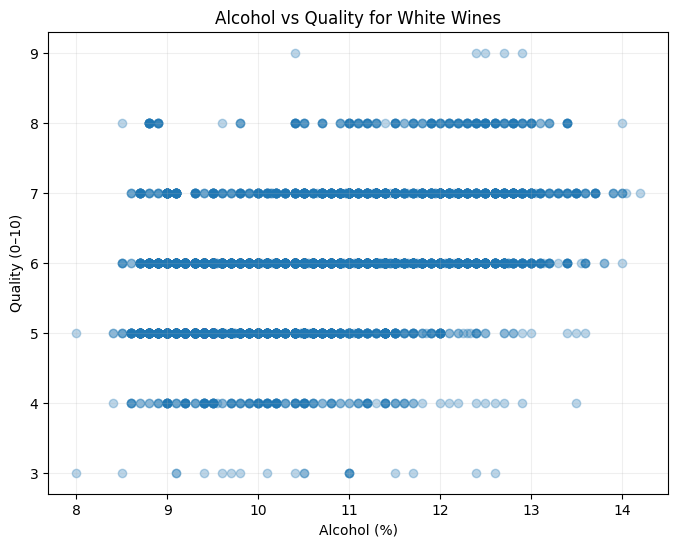

In [18]:
# Scatterplot: alcohol vs quality #

plt.figure(figsize=(8, 6))
plt.scatter(df_small["alcohol"], df_small["quality"], alpha=0.3)
plt.title("Alcohol vs Quality for White Wines")
plt.xlabel("Alcohol (%)")
plt.ylabel("Quality (0–10)")
plt.grid(True, alpha=0.2)
plt.show()

## Step 7: Bar Plot

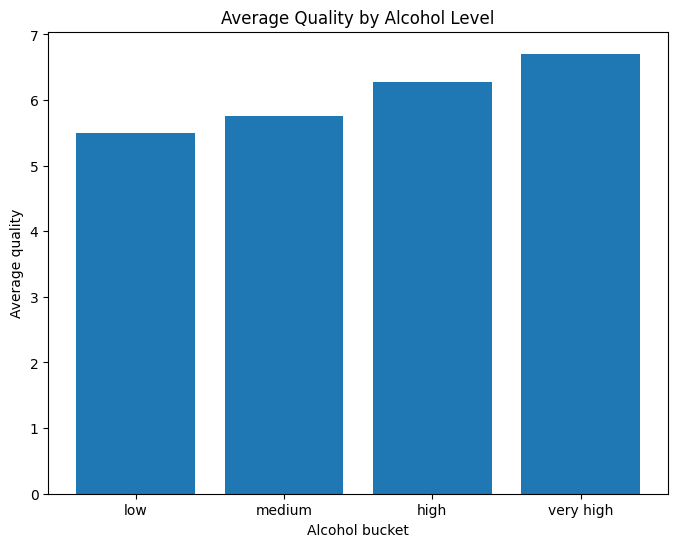

In [ ]:
# Bar plot: mean quality by alcohol bucket
plt.figure(figsize=(8, 6))
plt.bar(bucket_stats["alcohol_bucket"], bucket_stats["mean_quality"])
plt.title("Average Quality by Alcohol Level")
plt.xlabel("Alcohol bucket")
plt.ylabel("Average quality")
plt.show()

# Clear positive association

## Step 8: Histogram

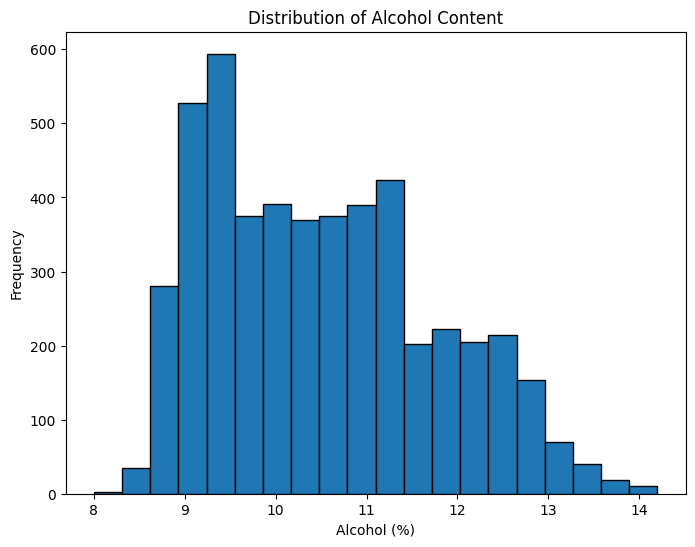

In [20]:
# Histogram of alcohol to show its distribution
plt.figure(figsize=(8, 6))
plt.hist(df_small["alcohol"], bins=20, edgecolor="black")
plt.title("Distribution of Alcohol Content")
plt.xlabel("Alcohol (%)")
plt.ylabel("Frequency")
plt.show()

## Conclusion: 

Based on the analysis of 4898 white wine samples from the UCI Wine Quality dataset, alcohol content shows a clear positive relationship with wine quality. The scatterplot reveals an upward trend, indicating that wines with higher alcohol percentages generally receive higher quality scores. This observation is supported by the correlation coefficient, which is approximately 0.44 and reflects a moderate positive linear association between alcohol content and quality.

The grouping analysis further supports this pattern. When wines are divided into alcohol level categories, the average quality score increases steadily from the lower alcohol levels to the higher ones. Wines in the higher alcohol groups tend to receive better quality ratings on average. Although alcohol content is not the only factor that influences quality, and other chemical attributes also contribute, alcohol stands out as one of the strongest individual predictors in the dataset.

Overall, the findings support the hypothesis that wines with higher alcohol content tend to achieve higher quality ratings. Alcohol content appears to be an important factor in evaluating wine quality, although it works alongside several other chemical characteristics.